In [1]:
print('hi')

hi


In [2]:
from modules.viz import MultiExperiment, metric_x_point, devplot
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def add_wt_col(df:pd.DataFrame, idx:int=1, colname:str='loss_weights'):
    return df[colname].apply(lambda x: x[idx]) # kld weight idx = 1

In [4]:
grid = MultiExperiment(
    experiment_dirs=[
        'output/2026-01-03_17h09m26s_grid_3a_NBreconstr_vae',
        'output/2026-01-03_17h59m11s_grid_3a_NBreconstr_vae',
        'output/2026-01-03_18h48m32s_grid_3a_NBreconstr_vae',
        'output/2026-01-03_19h44m28s_grid_3a_NBreconstr_vae',
        'output/2026-01-03_20h51m38s_grid_3a_NBreconstr_vae',
        'output/2026-01-03_21h37m10s_grid_3a_NBreconstr_vae'
    ],

    keys=['loss_weights'],
    out_dir='./experiments/grid_3a_NBreconstr_vae',
    # overwrite=True
)

grid.dev['kld_weight'] = add_wt_col(grid.dev)
grid.test['kld_weight'] = add_wt_col(grid.test)
grid.summary['kld_weight'] = add_wt_col(grid.summary)

Avoided overwriting 14 files. Call self.avoided_overwrite to see list, or run with overwrite=True to overwrite.


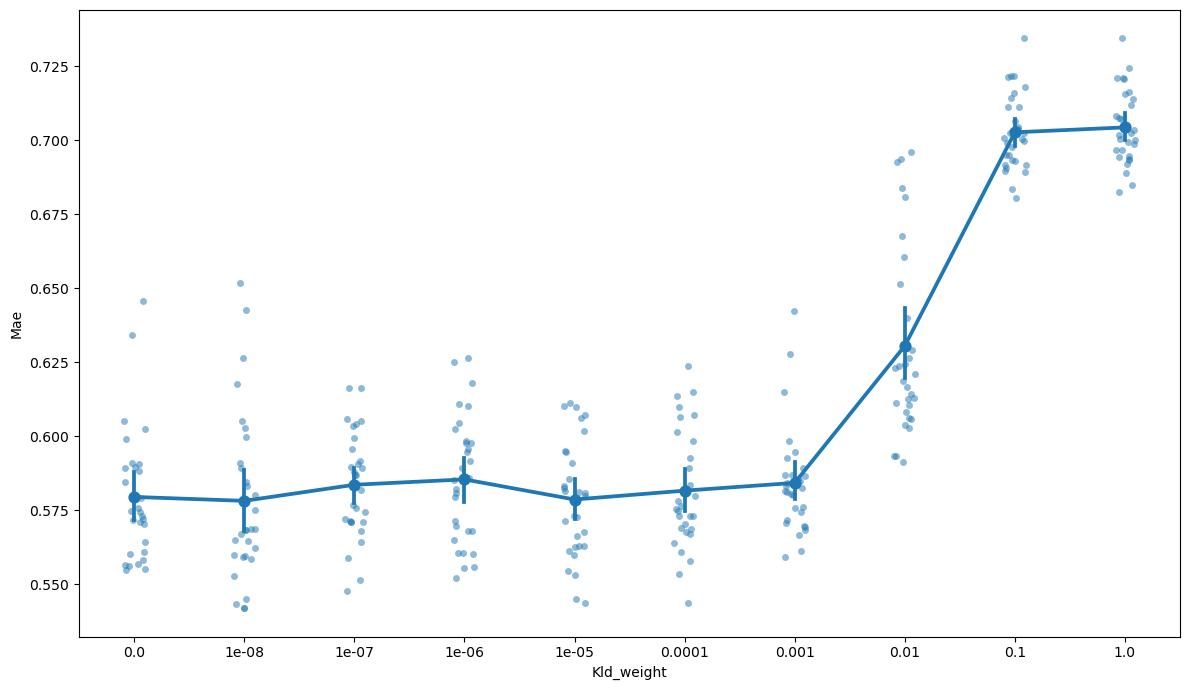

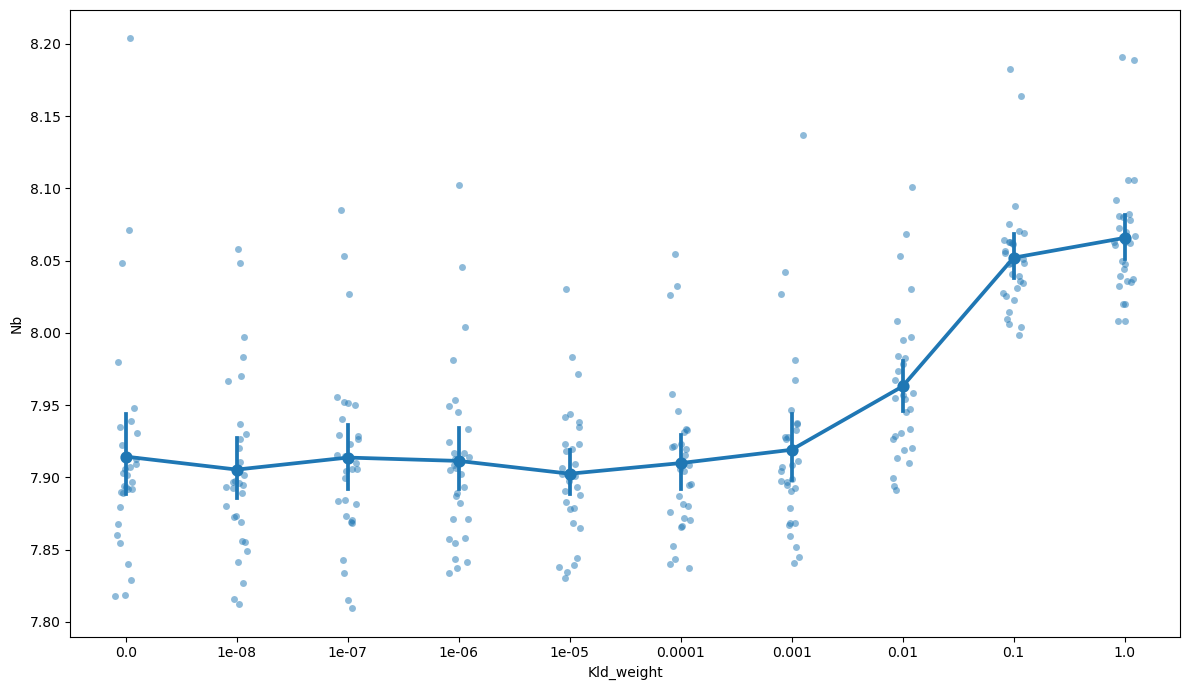

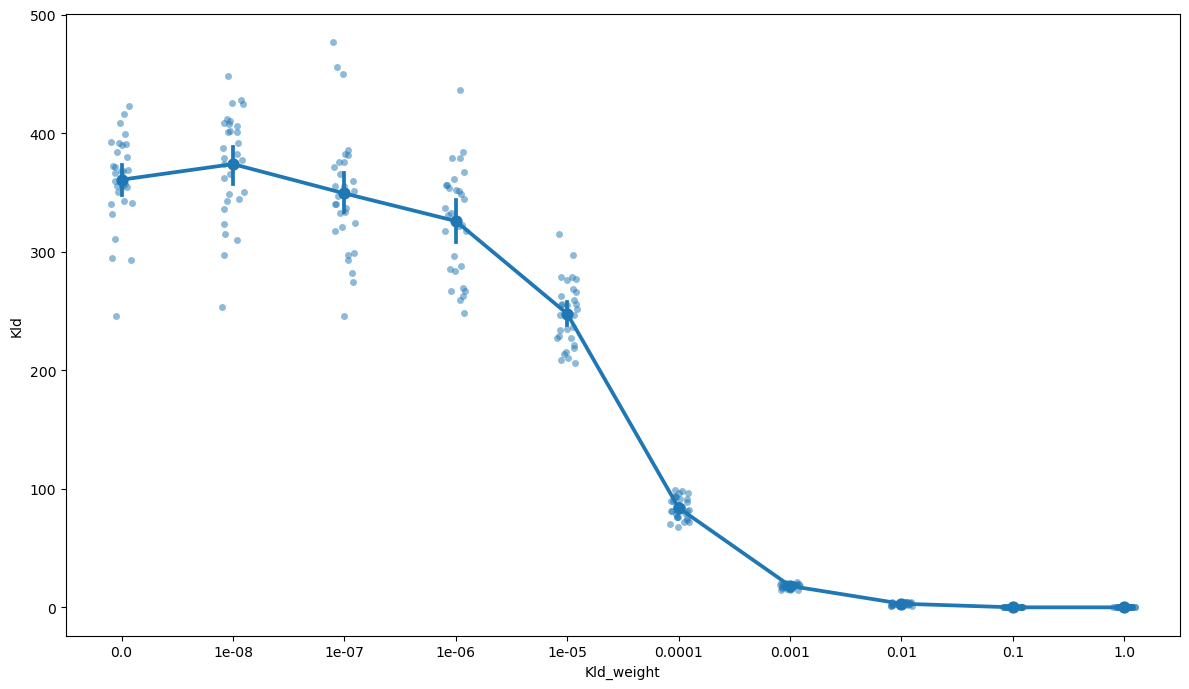

In [5]:
metric_x_point(
    df=grid.test,
    cols=['kld_weight'],
    metrics=['mae','nb','kld'],
    figsize=(12,7),
    strip=True,
    sig=False
)

---

In [6]:
figs = devplot(
    dev=grid.dev,
    summary=grid.summary,
    metrics=['loss','mae','nb','kld'],
    figsize=(12,7),
)

lossweights11


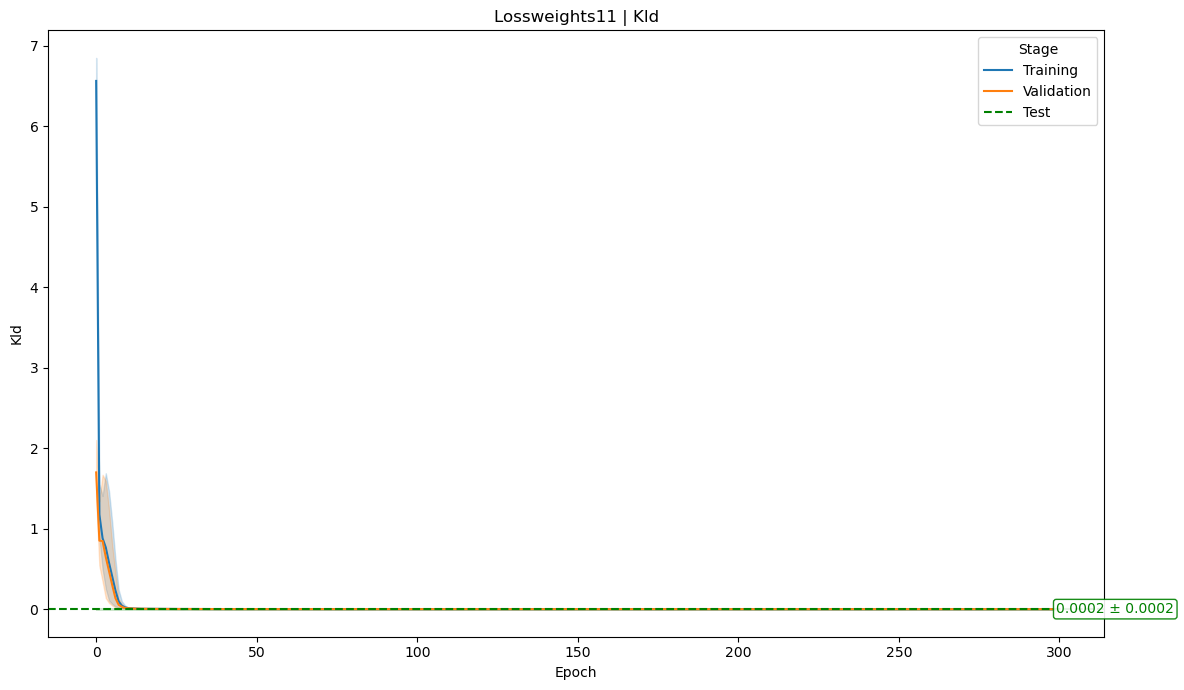

lossweights10.1


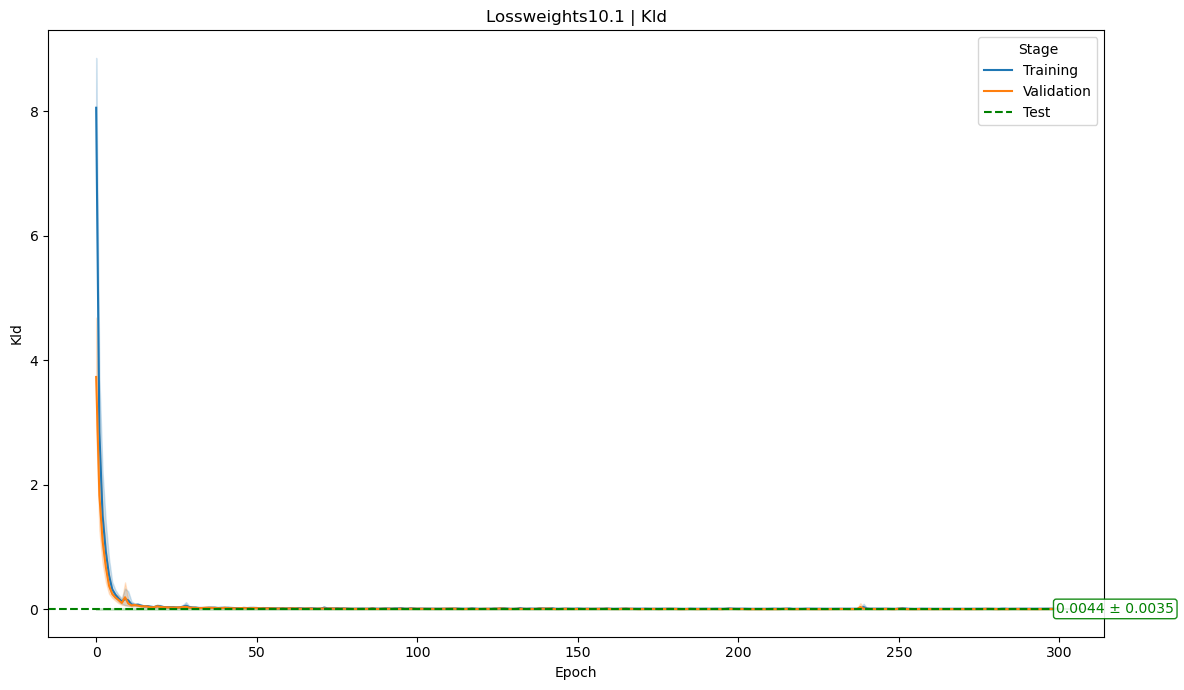

lossweights10.01


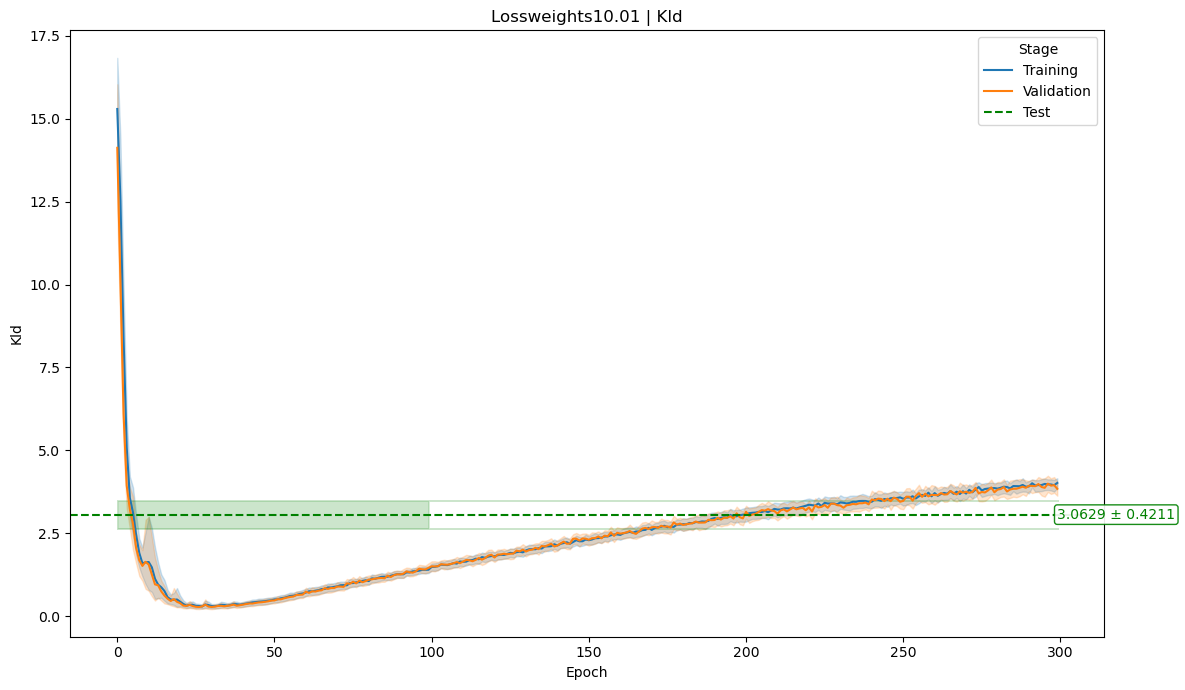

lossweights11e-3


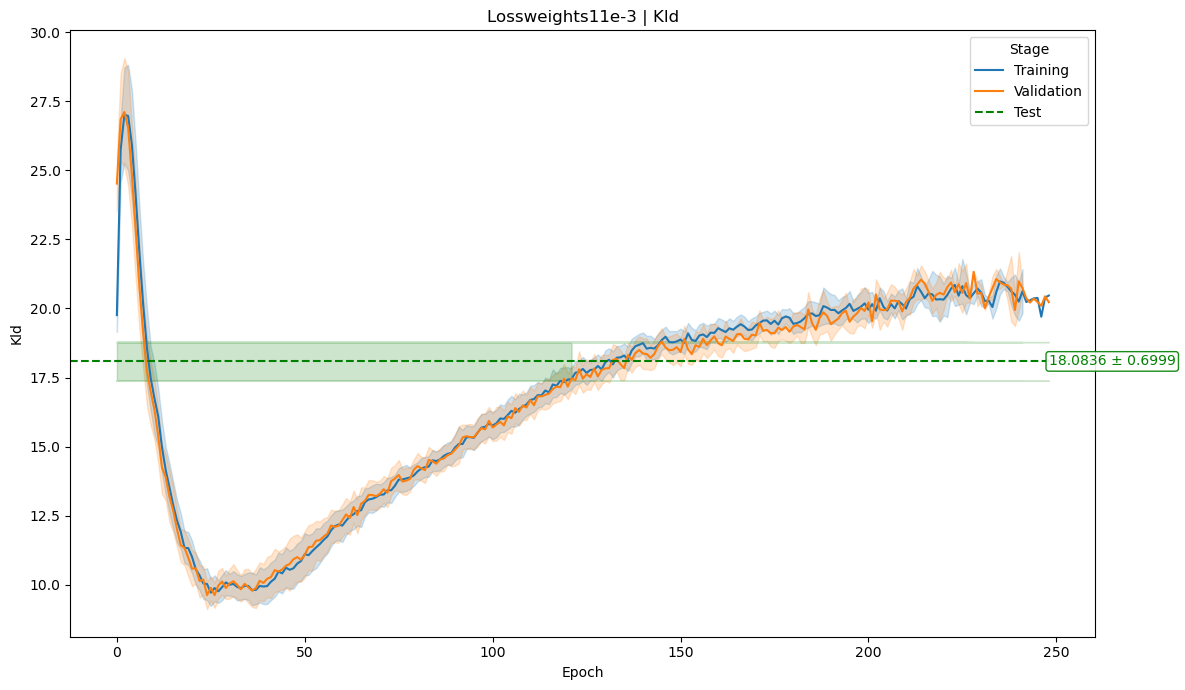

lossweights11e-4


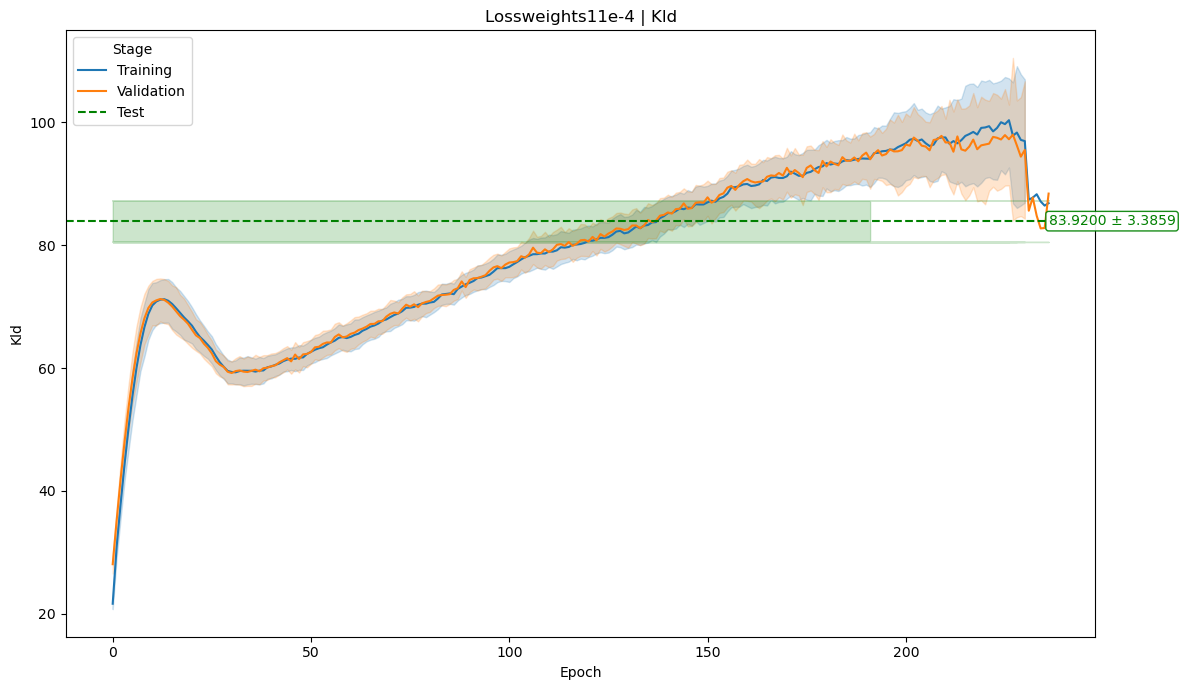

lossweights11e-5


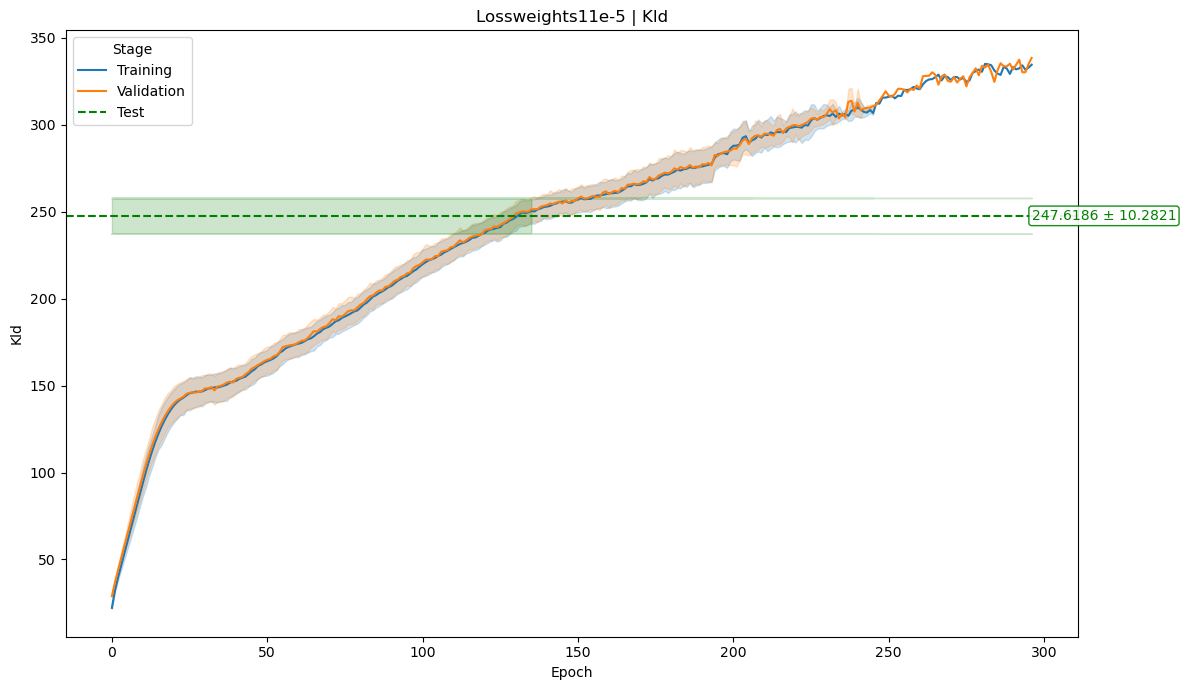

lossweights11e-6


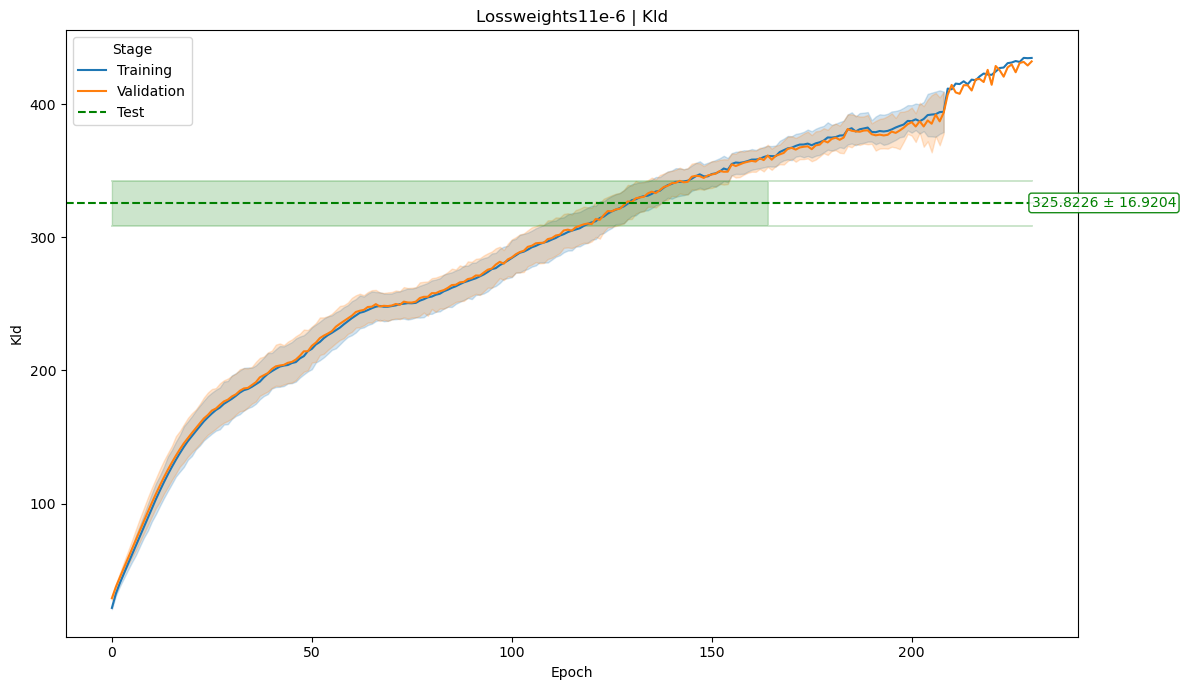

lossweights11e-7


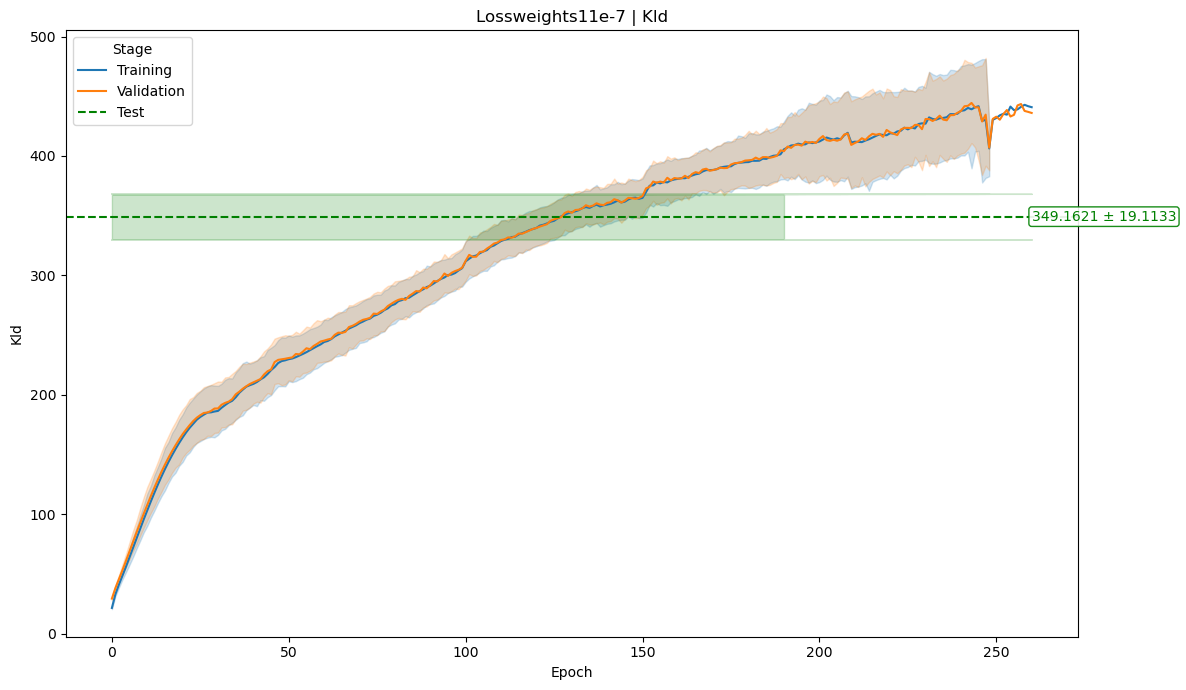

lossweights11e-8


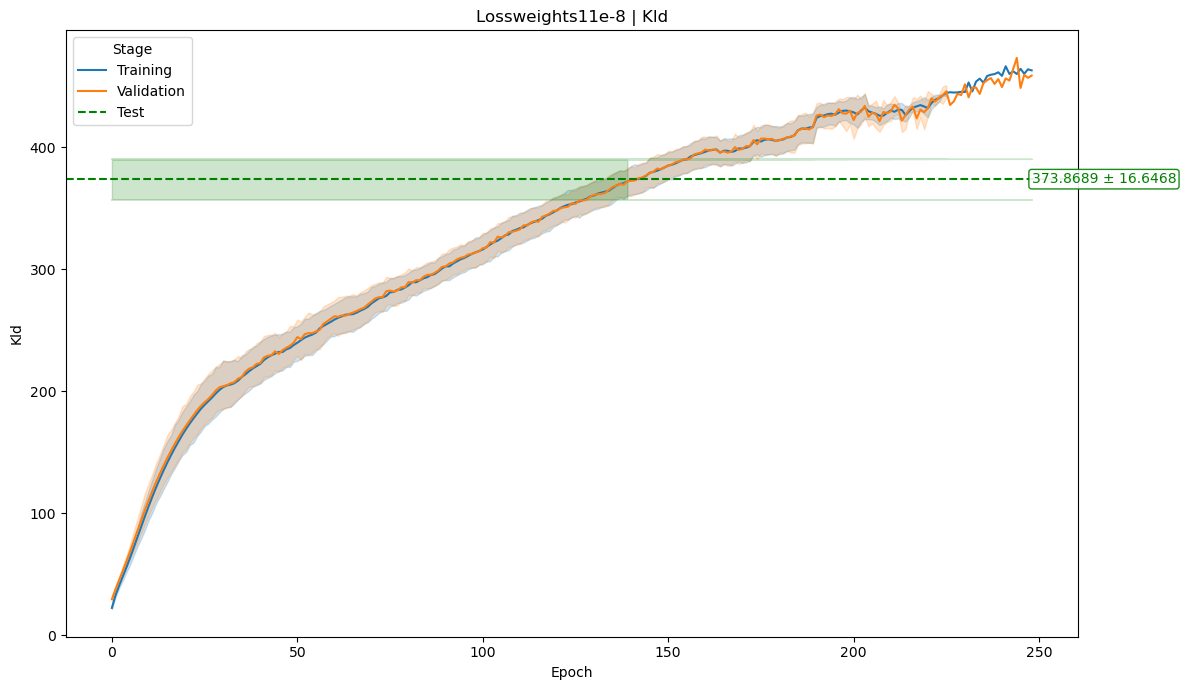

lossweights10


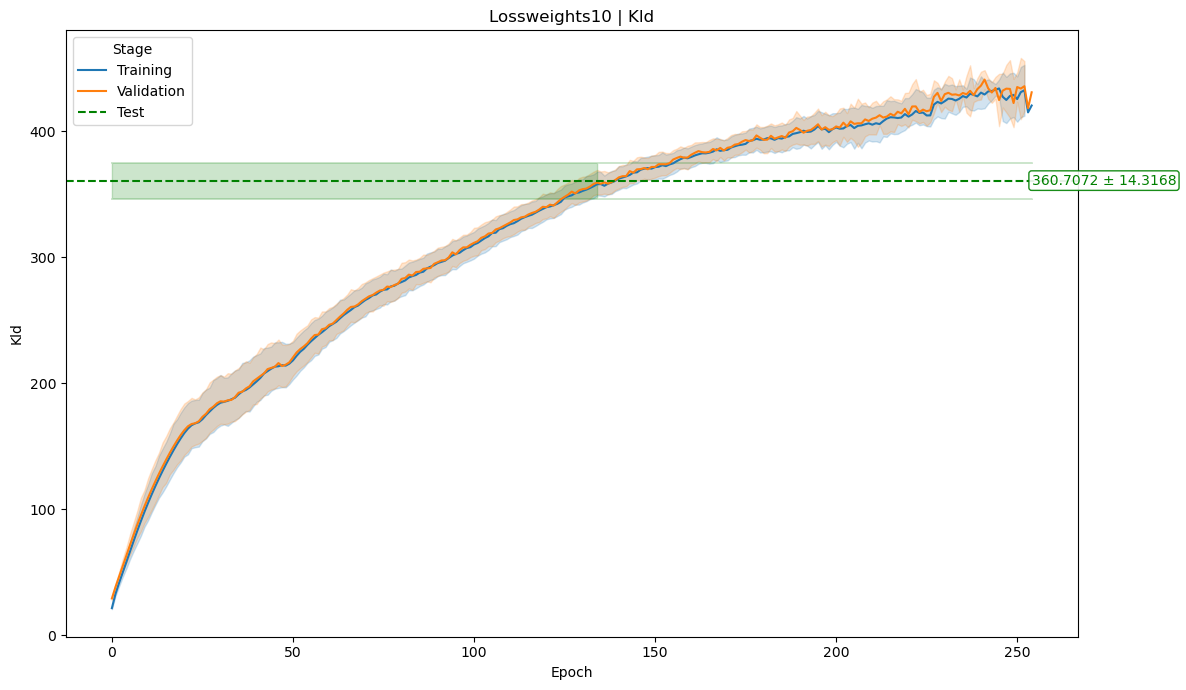

In [7]:
for key in figs.keys():
    print(key)
    display(figs[key]['kld'])

In [8]:
def multi_valplot(df:pd.DataFrame, y_col:str, hue:str, as_str:bool=False, figsize:tuple=(12,7)):
    d = df[df['metric']==y_col].copy()
    if as_str:
        d[hue] = d[hue].astype(str)
    plt.figure(figsize=figsize)
    sns.lineplot(data=d, x='epoch', y='value', hue=hue)
    plt.ylabel(y_col)
    plt.show()

In [9]:
grid.dev

,loss_weights,config,trial,epoch,stage,metric,value,kld_weight
0,"[1.0, 1.0]",lossweights11,0,0,Training,loss,16.379723,1.0
1,"[1.0, 1.0]",lossweights11,0,0,Training,mse,0.871661,1.0
2,"[1.0, 1.0]",lossweights11,0,0,Training,rmse,0.933628,1.0
3,"[1.0, 1.0]",lossweights11,0,0,Training,mae,0.636835,1.0
4,"[1.0, 1.0]",lossweights11,0,0,Training,r2,0.772241,1.0
...,...,...,...,...,...,...,...,...
802125,"[1.0, 0.0]",lossweights10,29,134,Validation,rmse,0.949670,0.0
802126,"[1.0, 0.0]",lossweights10,29,134,Validation,mae,0.587518,0.0
802127,"[1.0, 0.0]",lossweights10,29,134,Validation,r2,0.766688,0.0
802128,"[1.0, 0.0]",lossweights10,29,134,Validation,kld,400.985535,0.0


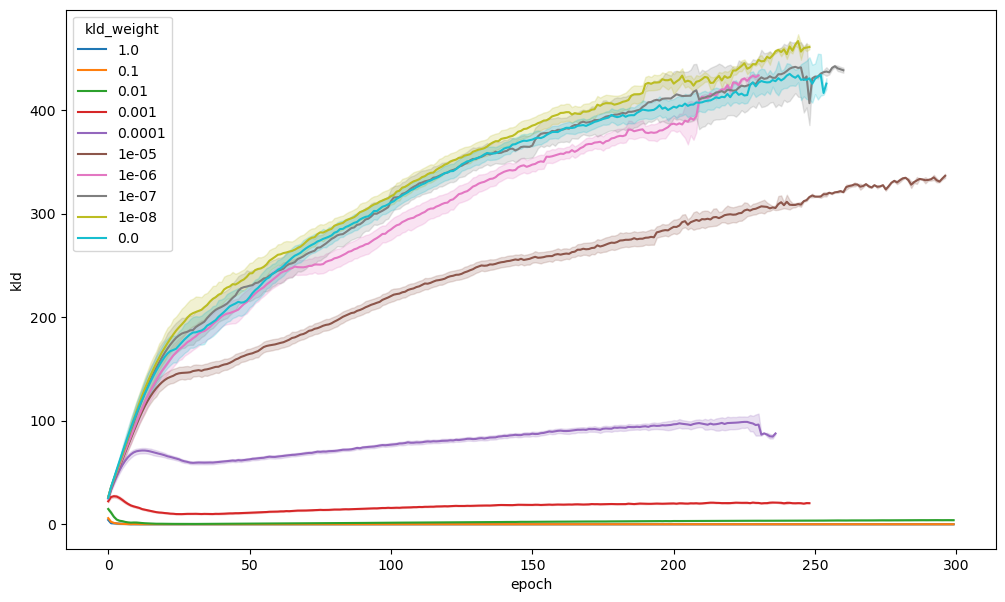

In [10]:
# 1e-4, 1e-5 look best?
multi_valplot(grid.dev, y_col='kld', hue='kld_weight', as_str=True)

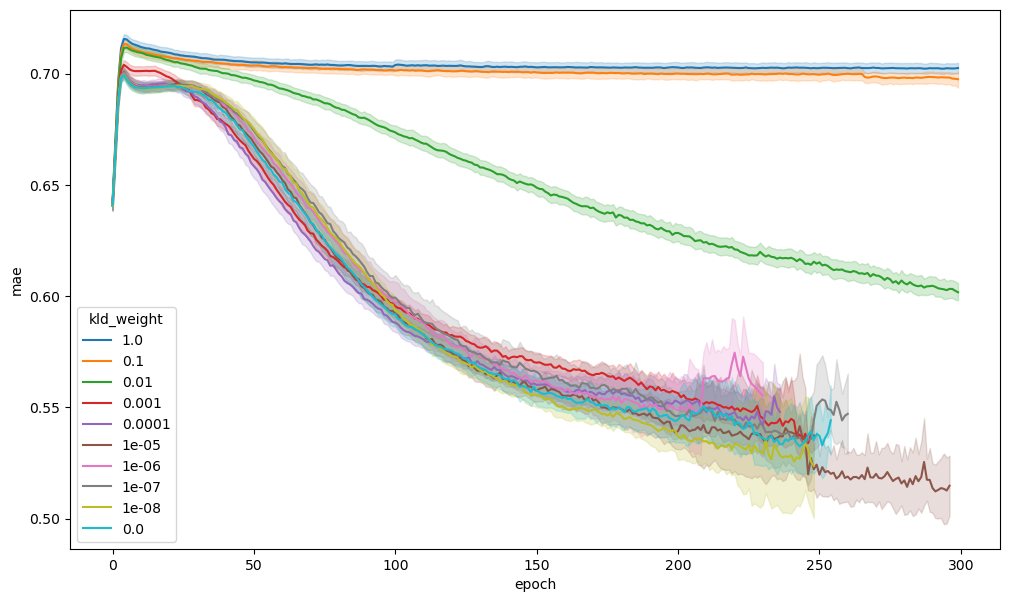

In [11]:
multi_valplot(grid.dev, y_col='mae', hue='kld_weight', as_str=True)

---

In [12]:
grid2 = MultiExperiment(
    experiment_dirs = [
        'output/2026-01-03_23h22m04s_grid_3a2_NBreconstr_vae_xtra',
        'output/2026-01-03_23h51m09s_grid_3a2_NBreconstr_vae_xtra',
    ],

    keys=['loss_weights'],
    out_dir='./experiments/grid_3a2_NBreconstr_vae_xtra',
    # overwrite=True
)

grid2.dev['kld_weight'] = add_wt_col(grid2.dev)
grid2.test['kld_weight'] = add_wt_col(grid2.test)
grid2.summary['kld_weight'] = add_wt_col(grid2.summary)

Avoided overwriting 9 files. Call self.avoided_overwrite to see list, or run with overwrite=True to overwrite.


---

In [31]:
# final thesis
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from statannotations.Annotator import Annotator

from matplotlib.lines import Line2D


In [43]:
df = grid.test.copy()
df['loss_weights'] = df['loss_weights'].apply(lambda x: x[1]) # kld weight idx = 1

df_mae = df[df['metric']=='mae']
df_kld = df[df['metric']=='kld']
display(df_mae.head(10))

df2 = grid2.test.copy()
df2['loss_weights'] = df2['loss_weights'].apply(lambda x: x[1]) # kld weight idx = 1

df2_mae = df2[df2['metric']=='mae']
df2_kld = df2[df2['metric']=='kld']
display(df2_mae.head(10))

,loss_weights,config,trial,metric,value,kld_weight
3,1.0,lossweights11,0,mae,0.701598,1.0
13,1.0,lossweights11,1,mae,0.707353,1.0
23,1.0,lossweights11,2,mae,0.689023,1.0
33,1.0,lossweights11,3,mae,0.711788,1.0
43,1.0,lossweights11,4,mae,0.691881,1.0
53,1.0,lossweights11,5,mae,0.720905,1.0
63,1.0,lossweights11,6,mae,0.734327,1.0
73,1.0,lossweights11,7,mae,0.716215,1.0
83,1.0,lossweights11,8,mae,0.693325,1.0
93,1.0,lossweights11,9,mae,0.708210,1.0


,loss_weights,config,trial,metric,value,kld_weight
3,0.001,lossweights11e-3,0,mae,0.566167,0.001
13,0.001,lossweights11e-3,1,mae,0.585673,0.001
23,0.001,lossweights11e-3,2,mae,0.568845,0.001
33,0.001,lossweights11e-3,3,mae,0.577384,0.001
43,0.001,lossweights11e-3,4,mae,0.567364,0.001
53,0.001,lossweights11e-3,5,mae,0.588628,0.001
63,0.001,lossweights11e-3,6,mae,0.571394,0.001
73,0.001,lossweights11e-3,7,mae,0.604876,0.001
83,0.001,lossweights11e-3,8,mae,0.592744,0.001
93,0.001,lossweights11e-3,9,mae,0.567880,0.001


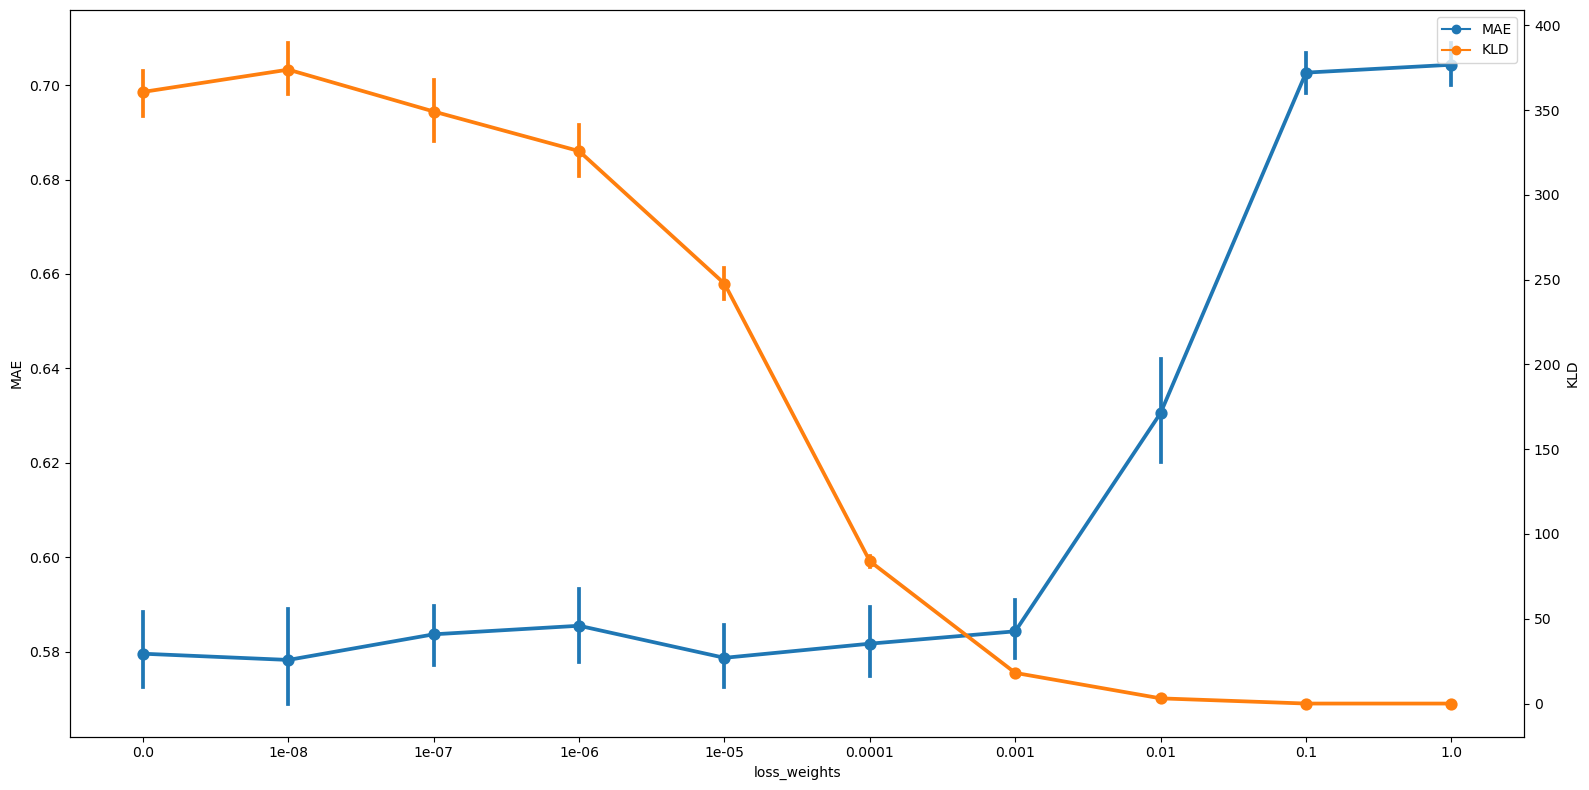

In [44]:
fig, ax1 = plt.subplots(figsize=(16,8))

# First pointplot
sns.pointplot(
    data=df_mae,
    x="loss_weights",
    y="value",
    ax=ax1,
    color="C0"
)

ax1.set_ylabel("MAE")

# Second y-axis
ax2 = ax1.twinx()

sns.pointplot(
    data=df_kld,
    x="loss_weights",
    y="value",
    ax=ax2,
    color="C1"
)

ax2.set_ylabel("KLD")

legend_elements = [
    Line2D([0], [0], color='C0', marker='o', label='MAE'),
    Line2D([0], [0], color='C1', marker='o', label='KLD')
]

ax1.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()

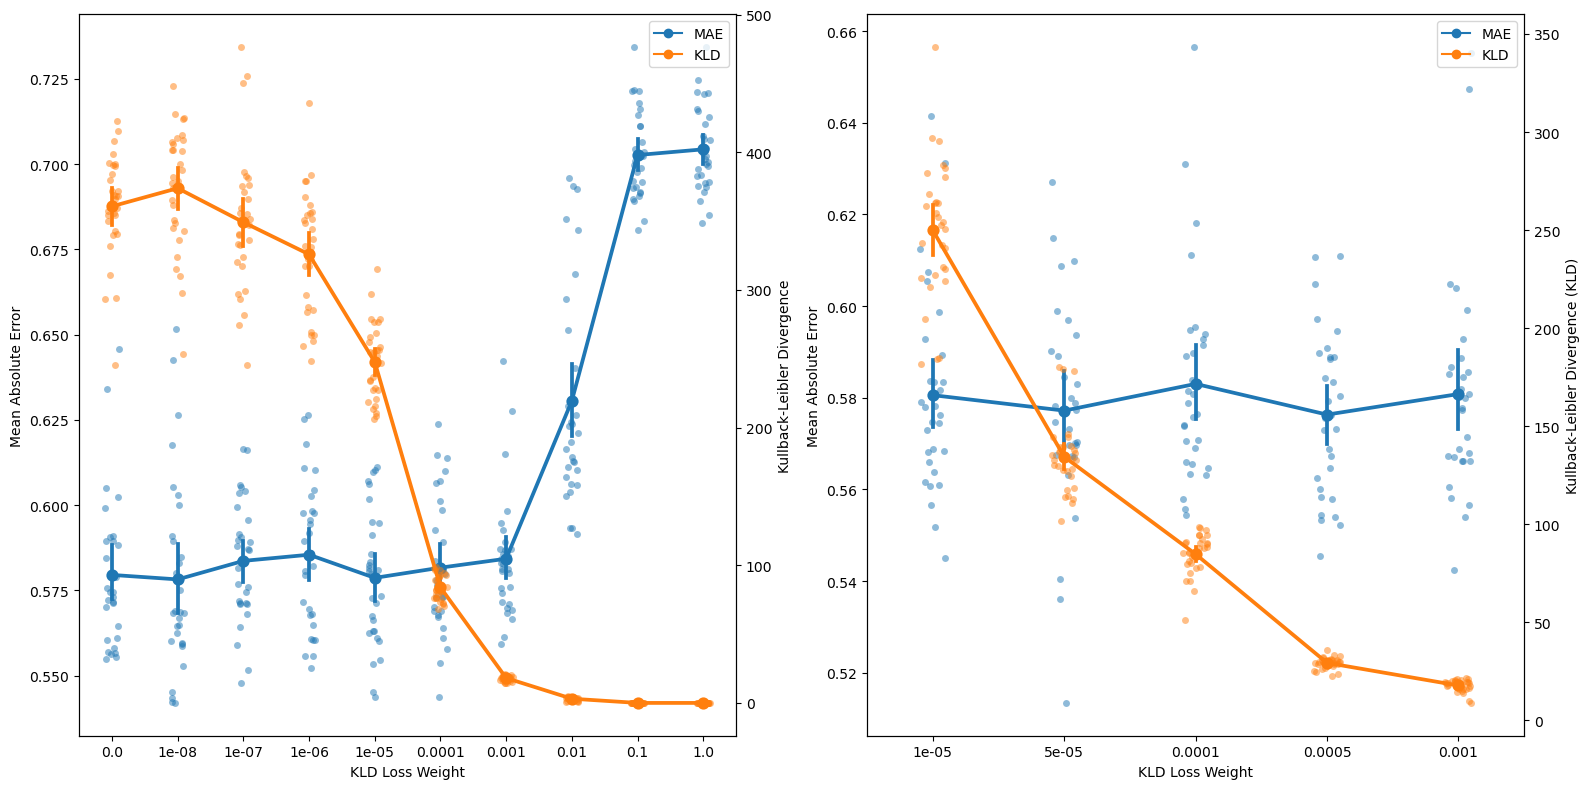

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16,8))

# First pointplot
sns.pointplot(data=df_mae, x="loss_weights", y="value", ax=axes[0], color="C0")
sns.stripplot(data=df_mae, x="loss_weights", y="value", ax=axes[0], color="C0", alpha=0.5)
axes[0].set_ylabel("Mean Absolute Error")

# Second y-axis
ax0_2 = axes[0].twinx()
sns.pointplot(data=df_kld, x="loss_weights", y="value", ax=ax0_2, color="C1")
sns.stripplot(data=df_kld, x="loss_weights", y="value", ax=ax0_2, color="C1", alpha=0.5)

ax0_2.set_ylabel("Kullback-Leibler Divergence")

legend_elements = [
    Line2D([0], [0], color='C0', marker='o', label='MAE'),
    Line2D([0], [0], color='C1', marker='o', label='KLD')
]

axes[0].legend(handles=legend_elements, loc='upper right')

###

# First pointplot
sns.pointplot(data=df2_mae, x="loss_weights", y="value", ax=axes[1], color="C0")
sns.stripplot(data=df2_mae, x="loss_weights", y="value", ax=axes[1], color="C0", alpha=0.5)
axes[1].set_ylabel("Mean Absolute Error")

# Second y-axis
ax1_2 = axes[1].twinx()
sns.pointplot(data=df2_kld, x="loss_weights", y="value", ax=ax1_2, color="C1")
sns.stripplot(data=df2_kld, x="loss_weights", y="value", ax=ax1_2, color="C1", alpha=0.5)

ax1_2.set_ylabel("Kullback-Leibler Divergence (KLD)")

legend_elements = [
    Line2D([0], [0], color='C0', marker='o', label='MAE'),
    Line2D([0], [0], color='C1', marker='o', label='KLD')
]

axes[1].legend(handles=legend_elements, loc='upper right')

axes[0].set_xlabel("KLD Loss Weight")
axes[1].set_xlabel("KLD Loss Weight")
plt.tight_layout()

---

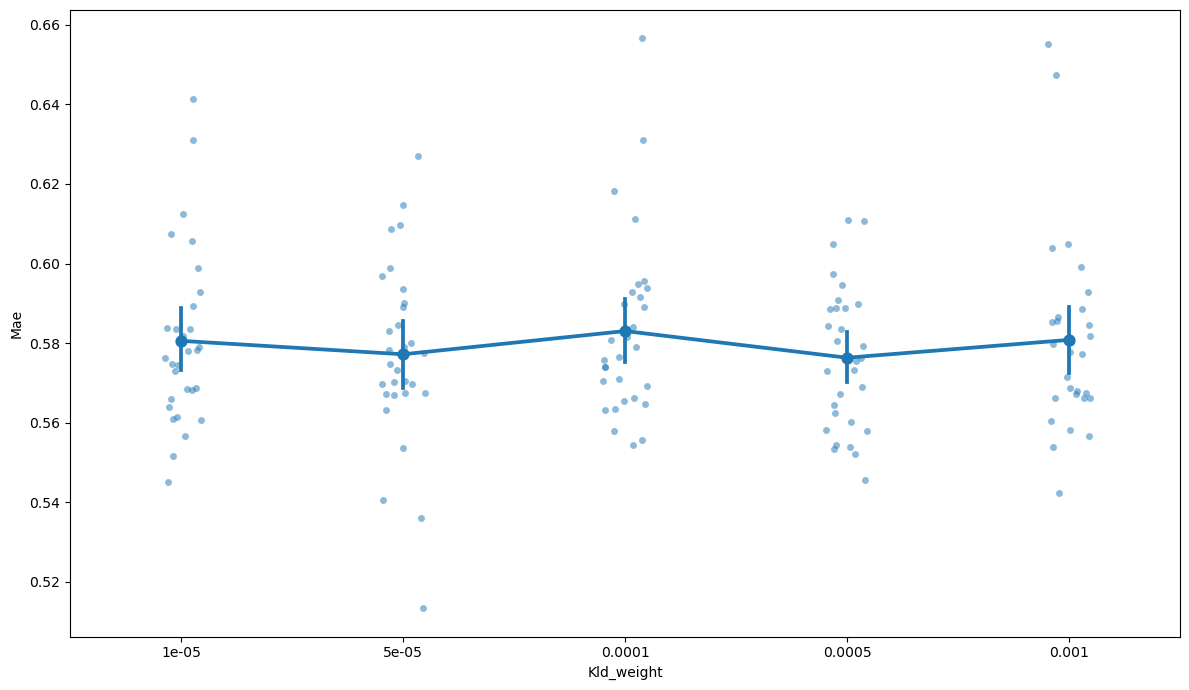

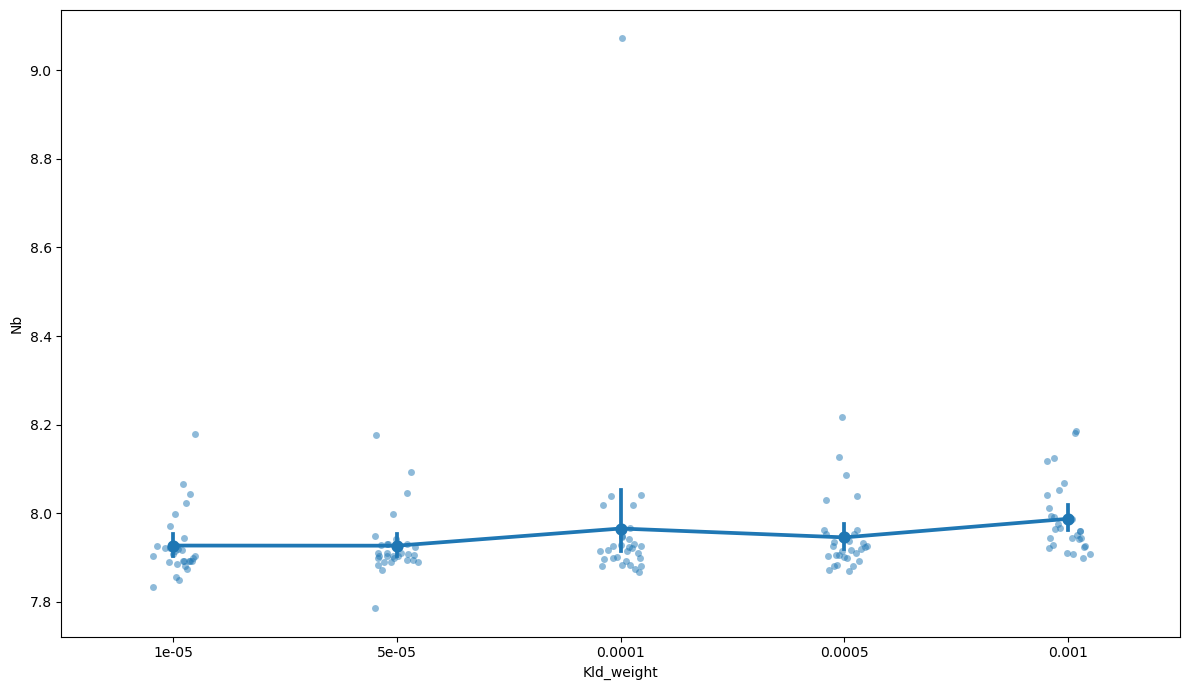

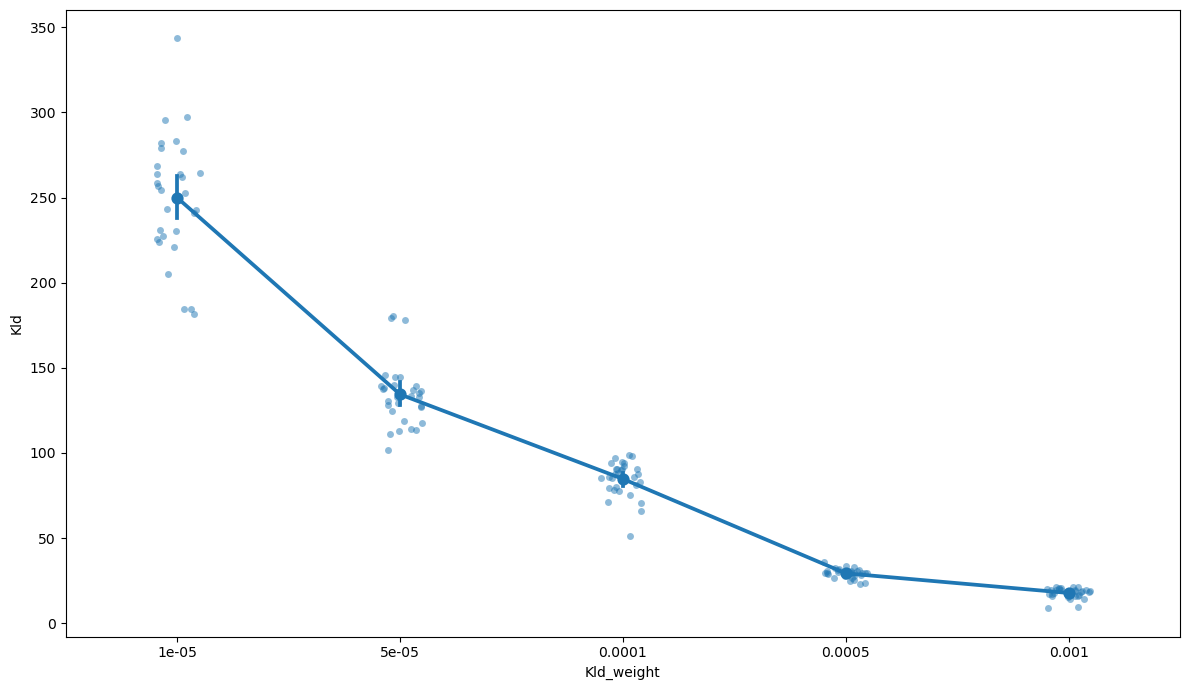

In [13]:
metric_x_point(
    df=grid2.test,
    cols=['kld_weight'],
    metrics=['mae','nb','kld'],
    figsize=(12,7),
    strip=True,
    sig=False
)

In [14]:
figs2 = devplot(
    dev=grid2.dev,
    summary=grid2.summary,
    metrics=['loss','mae','nb','kld'],
    figsize=(12,7),
)

lossweights11e-3


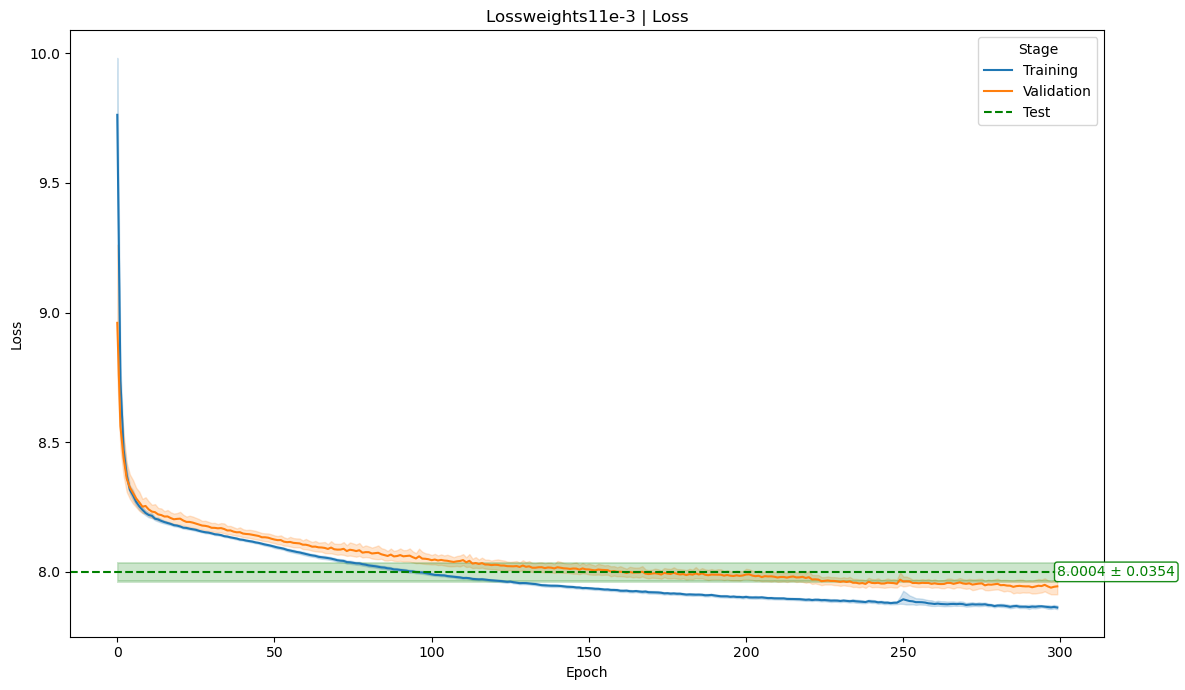

lossweights15e-4


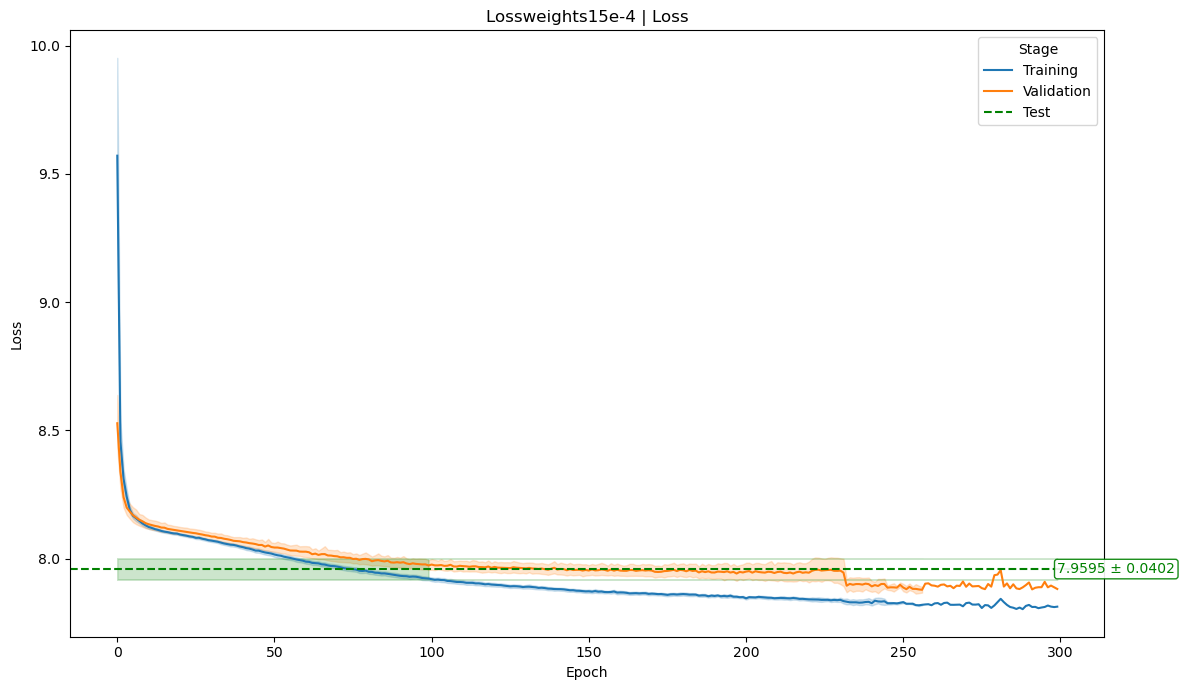

lossweights11e-4


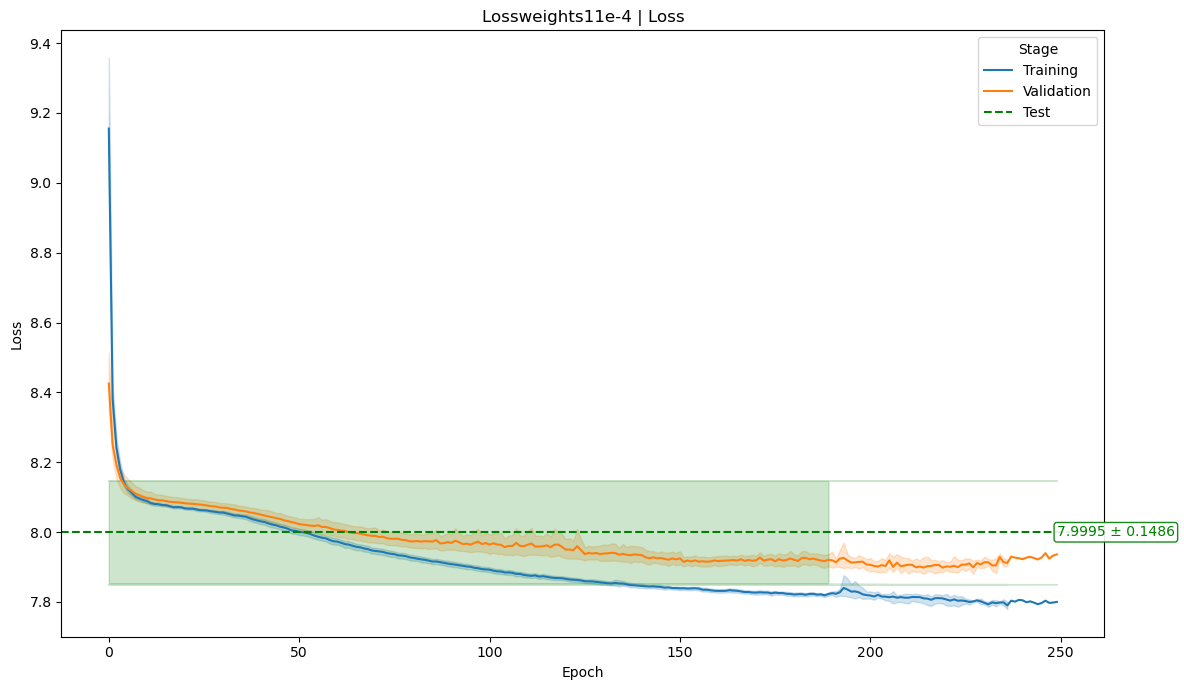

lossweights15e-5


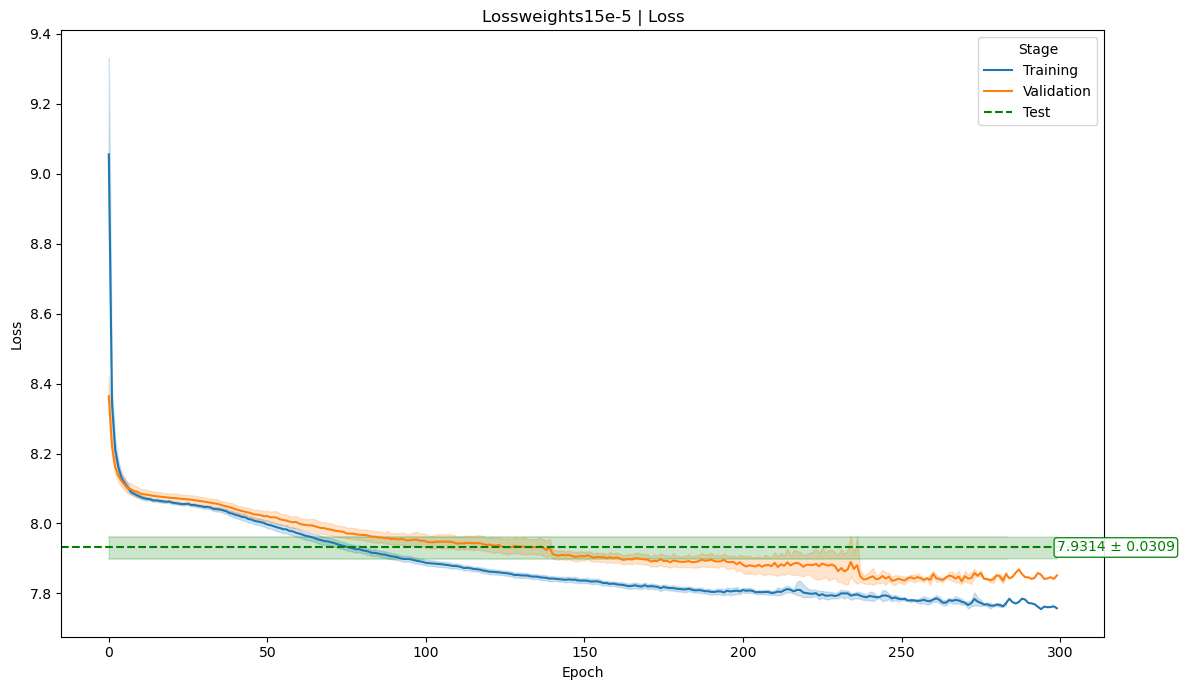

lossweights11e-5


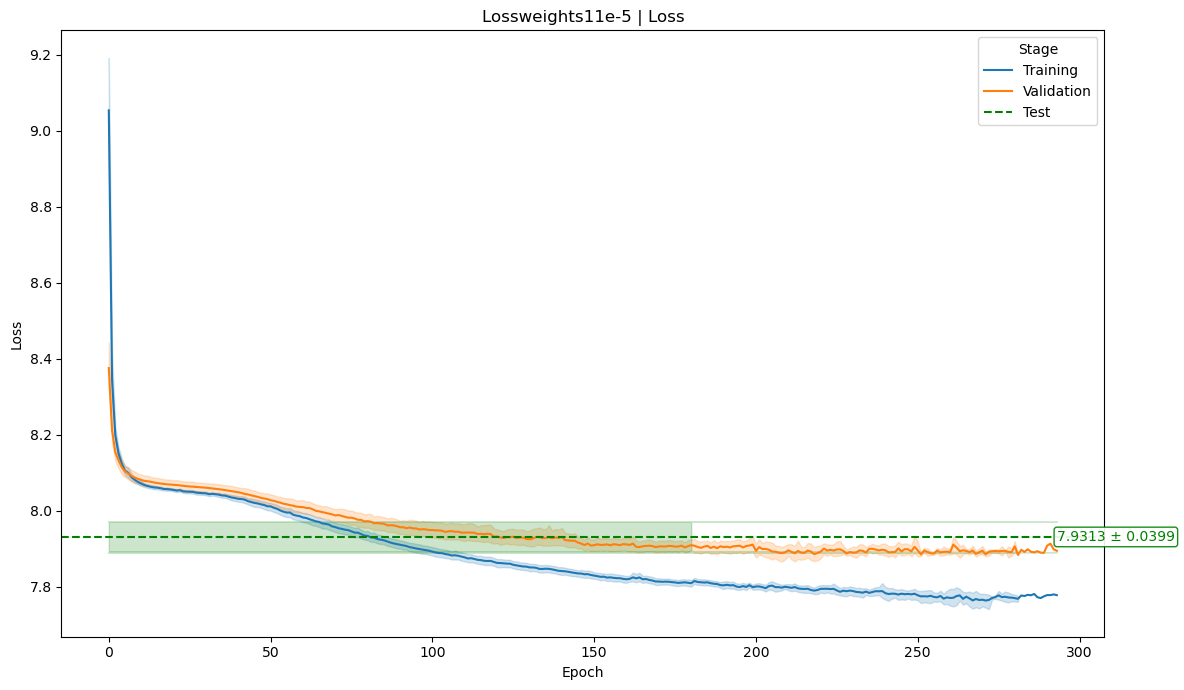

In [15]:
for key in figs2.keys():
    print(key)
    display(figs2[key]['loss'])

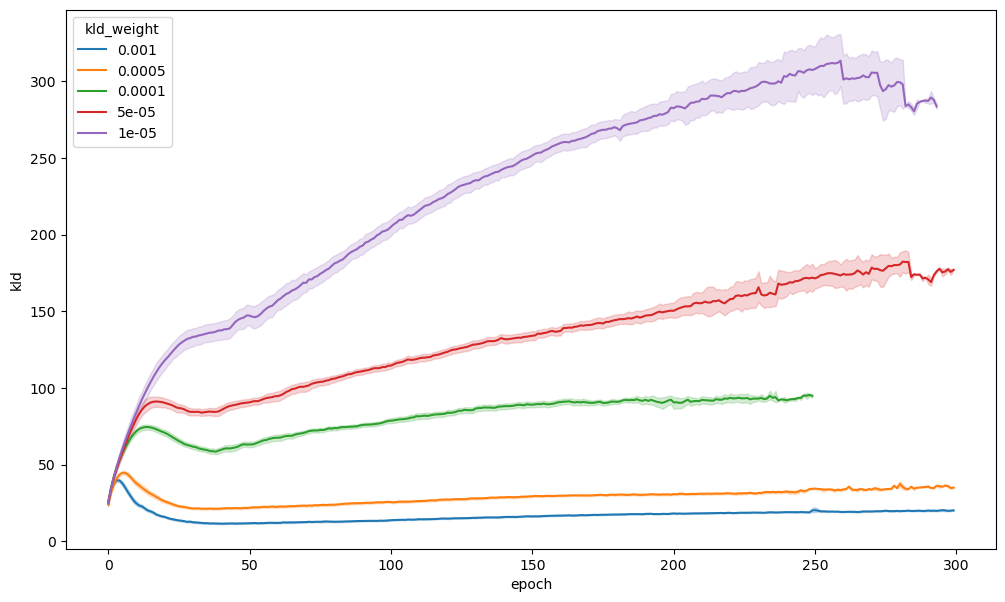

In [16]:
# 1e-4 looks best: most stable KLD and lowest MAE
multi_valplot(grid2.dev, y_col='kld', hue='kld_weight', as_str=True)

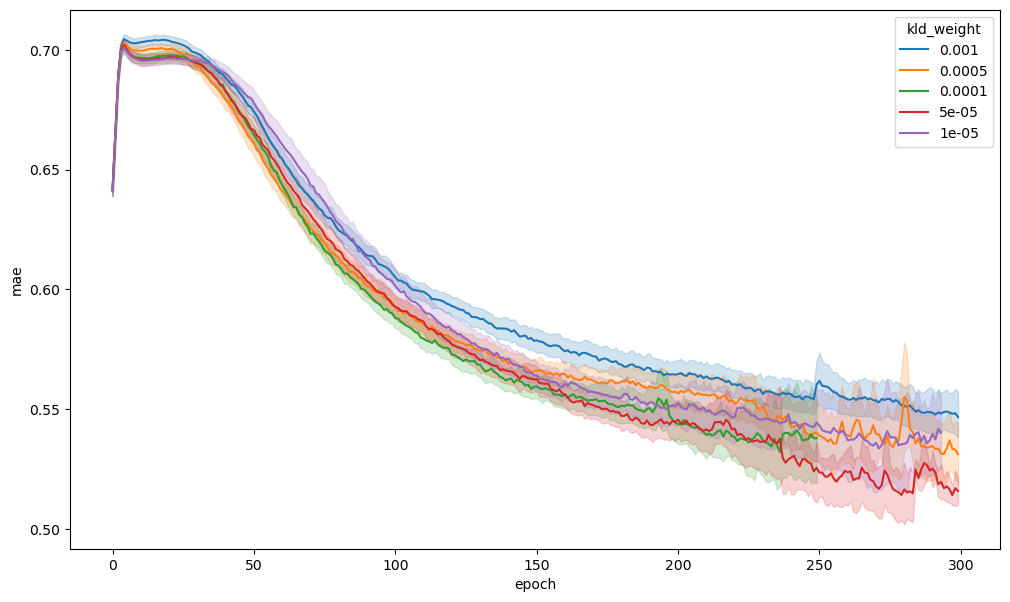

In [17]:
multi_valplot(grid2.dev, y_col='mae', hue='kld_weight', as_str=True)

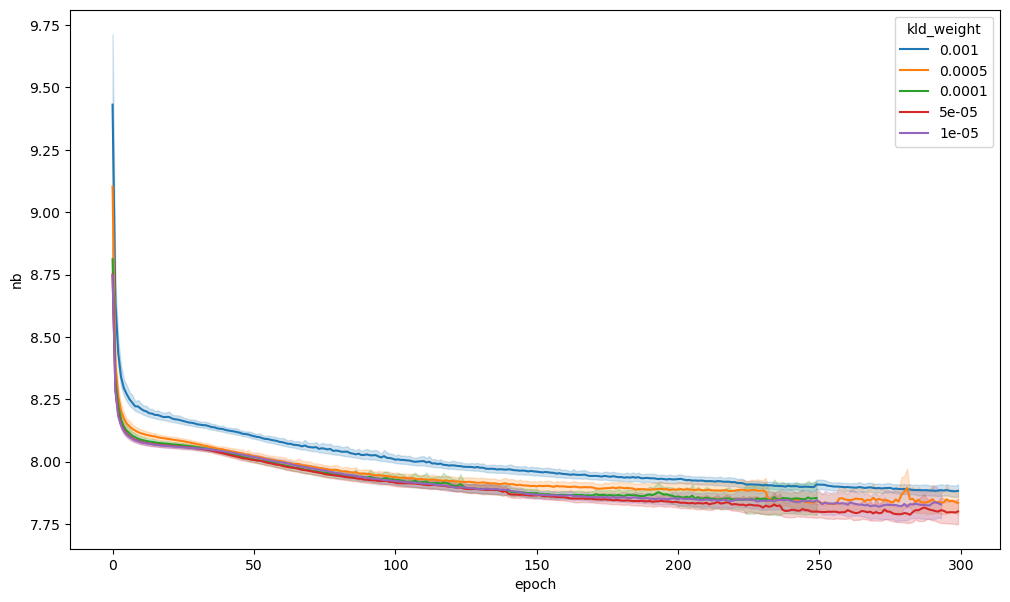

In [18]:
multi_valplot(grid2.dev, y_col='nb', hue='kld_weight', as_str=True)

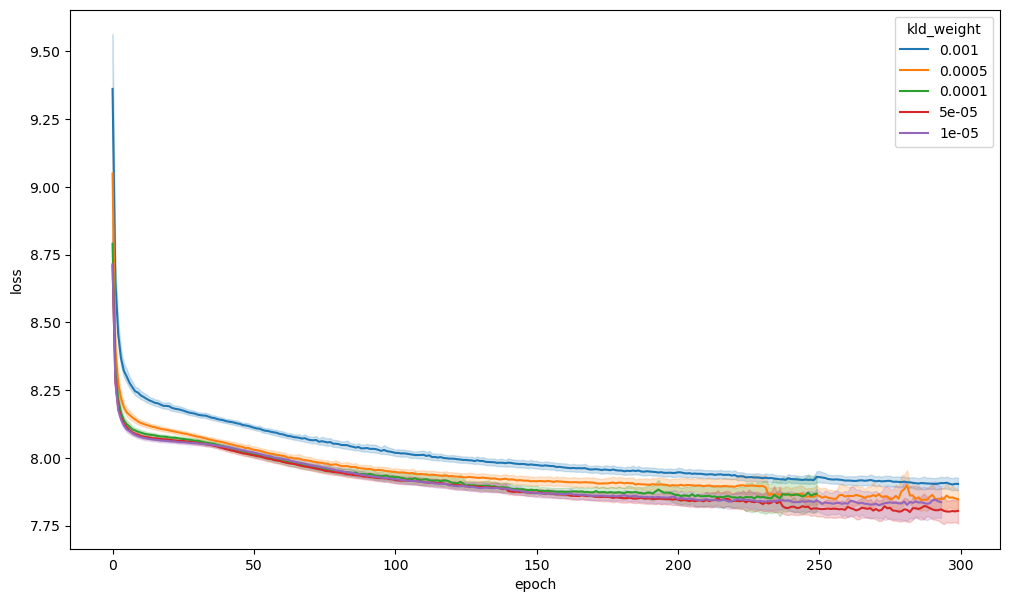

In [19]:
multi_valplot(grid2.dev, y_col='loss', hue='kld_weight', as_str=True)

---

In [58]:
def multi_valplot2(
    df: pd.DataFrame,
    y_col: str,
    hue: str,
    as_str: bool = False,
    figsize: tuple = (12, 7),
    ax=None
):
    d = df[df["metric"] == y_col].copy()

    if as_str:
        d[hue] = d[hue].astype(str)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    sns.lineplot(
        data=d,
        x="epoch",
        y="value",
        hue=hue,
        ax=ax
    )

    ax.set_ylabel(y_col)

    return fig, ax

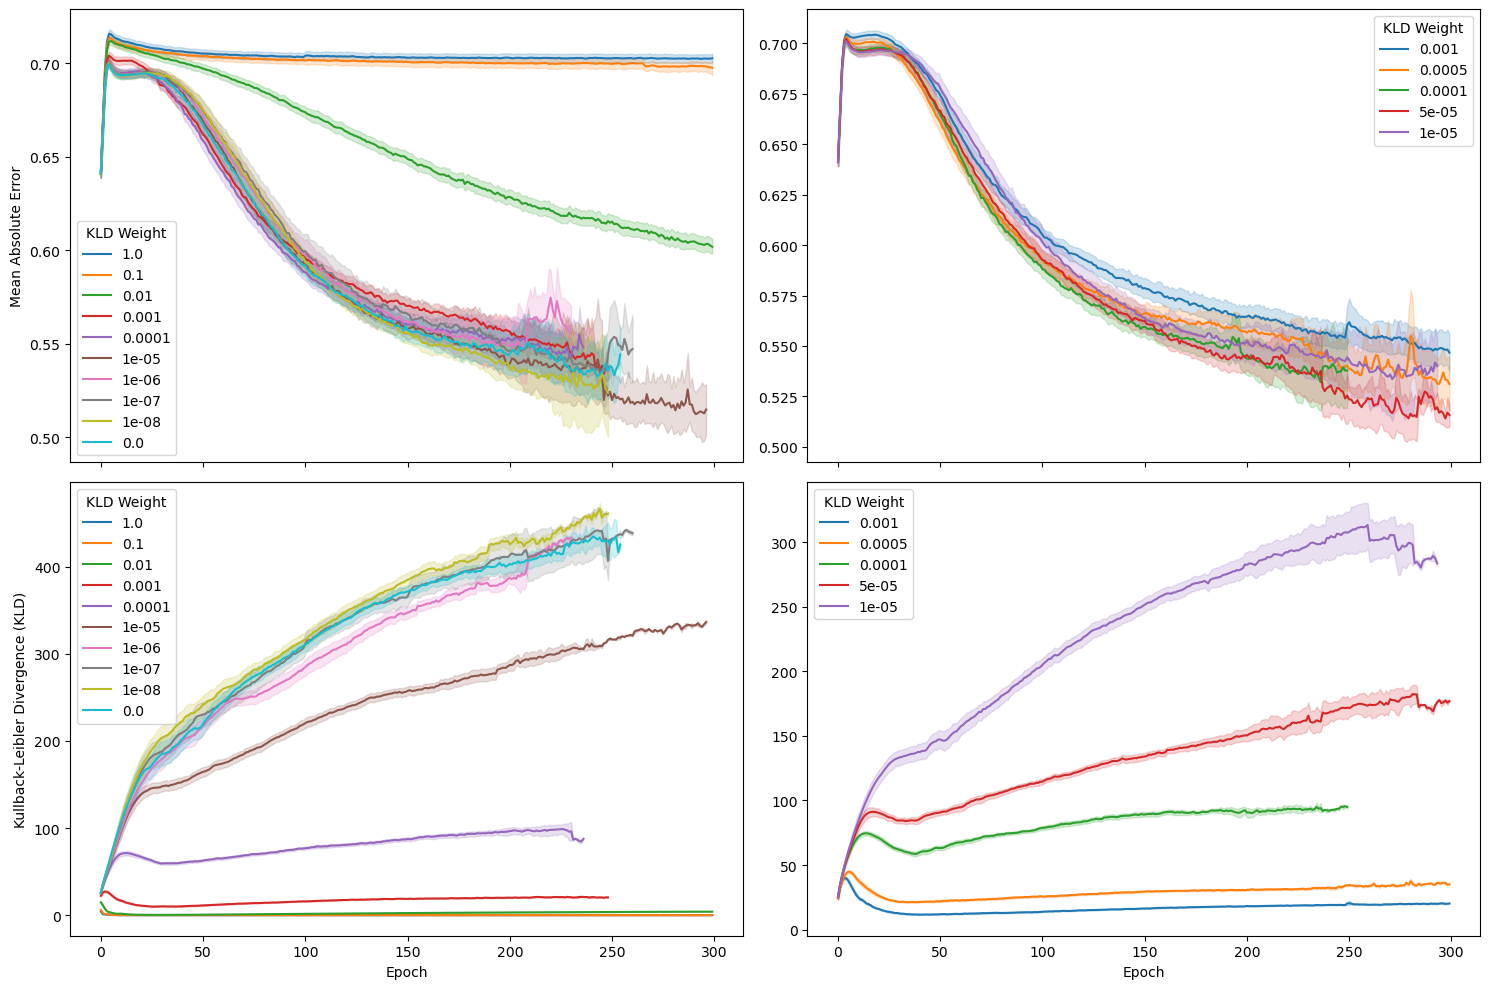

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(15,10), sharex=True)

multi_valplot2(grid.dev, y_col='mae', hue='kld_weight', as_str=True, ax=axes[0,0])
multi_valplot2(grid.dev, y_col='kld', hue='kld_weight', as_str=True, ax=axes[1,0])
multi_valplot2(grid2.dev, y_col='mae', hue='kld_weight', as_str=True, ax=axes[0,1])
multi_valplot2(grid2.dev, y_col='kld', hue='kld_weight', as_str=True, ax=axes[1,1])

axes[0,0].set_ylabel("Mean Absolute Error")
axes[1,0].set_ylabel("Kullback-Leibler Divergence (KLD)")
axes[0,1].set_ylabel("")
axes[1,1].set_ylabel("")

axes[0,0].set_xlabel("")
axes[1,0].set_xlabel("Epoch")
axes[0,1].set_xlabel("")
axes[1,1].set_xlabel("Epoch")

for ax in axes.flat:
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("KLD Weight")

plt.tight_layout()
